# Semantic Notes Search System

### Step 1: Define and Preprocess the Document

First, we'll define a sample document as a multi-line string. In a real-world application, this would typically be loaded from a file (e.g., PDF, text file, web page).

We'll then split this document into smaller, manageable chunks. The size of these chunks is crucial for effective retrieval; chunks that are too large might contain irrelevant information, while chunks that are too small might lack sufficient context.

In [ ]:
# Sample Document (replace with your actual notes/document)
document = """\nVectors are fundamental in data science, representing quantities with magnitude and direction. They are typically implemented using NumPy arrays.\n
Vector norms, like L1, L2 (Euclidean), and L-infinity, measure a vector's length or magnitude. The L2 norm is the most common for general distance calculations.\n
Linear combinations and dot products are essential operations. A dot product of zero indicates orthogonal (perpendicular) vectors.\n
Cosine similarity measures the angle between two vectors, indicating their directional similarity, regardless of magnitude. It's widely used in NLP for document similarity and recommendation systems.\n
Machine learning models, especially in NLP and Computer Vision, heavily rely on converting data into vector representations (embeddings). Word2Vec, for instance, creates dense word embeddings.\n
K-Nearest Neighbors (KNN) is a supervised algorithm that uses distance metrics (often Euclidean distance) to classify or regress new data points based on their 'K' nearest neighbors.\n
K-Means Clustering is an unsupervised algorithm for grouping data points into 'K' clusters, typically using Euclidean distance to assign points to the nearest centroid. It's distinct from KNN in its learning type and goal.\n
Image processing also involves vectors. An image can be represented as a multi-dimensional NumPy array, where each pixel's color information (e.g., RGB values) forms a vector. Operations like grayscale conversion manipulate these pixel vectors.\n"""

# Split the document into chunks (simple split by newline for demonstration)
# In a real application, you might use more sophisticated text splitting techniques (e.g., based on token count, paragraph structure)
note_chunks = [chunk.strip() for chunk in document.split('\n\n') if chunk.strip()]

print(f"Original document length: {len(document)} characters")
print(f"Number of chunks created: {len(note_chunks)}")
print("\nFirst 3 chunks:")
for i, chunk in enumerate(note_chunks[:3]):
    print(f"Chunk {i+1}: {chunk[:100]}...") # Display first 100 characters of each chunk

Original document length: 1490 characters
Number of chunks created: 8

First 3 chunks:
Chunk 1: Vectors are fundamental in data science, representing quantities with magnitude and direction. They ...
Chunk 2: Vector norms, like L1, L2 (Euclidean), and L-infinity, measure a vector's length or magnitude. The L...
Chunk 3: Linear combinations and dot products are essential operations. A dot product of zero indicates ortho...


### Step 2: Generate Vector Embeddings

We will use a pre-trained `sentence-transformers` model to convert each text chunk into a high-dimensional vector (embedding). These embeddings capture the semantic meaning of the text, allowing us to compare the similarity between chunks and queries.

Explanation

In [ ]:

import numpy as np

sentences = [
    "i love ai",
    "i love coding",
    "i enjoy ai",
    "ai is fun",
    "coding is fun"
]

words = list(set(" ".join(sentences).split()))
word_to_id = {w: i for i, w in enumerate(words)}
id_to_word = {i: w for w, i in word_to_id.items()}

print(word_to_id)

training_data = []

for sentence in sentences:
    tokens = sentence.split()
    for i in range(len(tokens) - 1):
        input_word = tokens[i]
        target_word = tokens[i + 1]
        training_data.append((input_word, target_word))

print(training_data)

vocab_size = len(words)
embedding_dim = 5

# random vectors for each word
embeddings = np.random.rand(vocab_size, embedding_dim)
print(embeddings)
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def predict(word):
    word_id = word_to_id[word]
    word_vec = embeddings[word_id]

    similarities = []

    for i in range(vocab_size):
        if i == word_id:
            similarities.append(-1)  # ignore itself
            continue

        sim = cosine_similarity(word_vec, embeddings[i])
        similarities.append(sim)

    predicted_id = np.argmax(similarities)
    return id_to_word[predicted_id]

print(predict("i"))
print(predict("love"))

learning_rate = 0.01

for epoch in range(500):
    for input_word, target_word in training_data:
        input_id = word_to_id[input_word]
        target_id = word_to_id[target_word]

        input_vec = embeddings[input_id]
        target_vec = embeddings[target_id]

        # move input vector closer to target
        embeddings[input_id] += learning_rate * (target_vec - input_vec)

print(predict("i"))     # should give "love" or "enjoy"
print(predict("love"))  # should give "ai" or "coding"

{'enjoy': 0, 'is': 1, 'i': 2, 'ai': 3, 'fun': 4, 'coding': 5, 'love': 6}
[('i', 'love'), ('love', 'ai'), ('i', 'love'), ('love', 'coding'), ('i', 'enjoy'), ('enjoy', 'ai'), ('ai', 'is'), ('is', 'fun'), ('coding', 'is'), ('is', 'fun')]
[[6.47315801e-03 2.38601808e-01 2.81435023e-01 3.28792139e-01
  5.52731862e-01]
 [2.04052069e-01 9.46656093e-01 7.97797251e-01 1.98012207e-01
  1.33995872e-01]
 [4.51922483e-01 2.50699373e-01 7.50962639e-01 7.99979469e-01
  2.02882353e-01]
 [8.66601687e-01 4.22264637e-01 1.24905200e-01 8.01042675e-01
  1.79010235e-01]
 [2.90967533e-01 7.99711730e-01 9.47777732e-01 1.54397382e-01
  3.43567237e-01]
 [1.05194136e-04 6.00092418e-01 8.42180563e-01 8.85809437e-01
  3.50938724e-02]
 [5.63114555e-01 4.10307013e-02 3.26906385e-01 3.36470396e-01
  5.63591099e-01]]
coding
i
enjoy
ai


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating embeddings for document chunks...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embeddings shape: (8, 384) (Number of chunks, Embedding dimension)
First embedding (first 5 elements): [ 0.00695985 -0.04092308 -0.0702056  -0.0572193   0.01348892]...


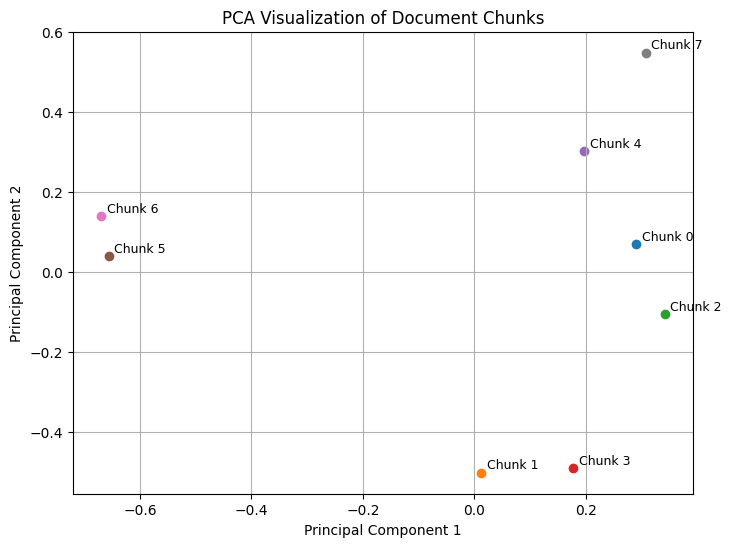

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Load a pre-trained sentence embedding model
# 'all-MiniLM-L6-v2' is a good balance of speed and performance
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

print("Generating embeddings for document chunks...")
note_embeddings = embedding_model.encode(note_chunks, show_progress_bar=True)

print(f"Embeddings shape: {note_embeddings.shape} (Number of chunks, Embedding dimension)")
print(f"First embedding (first 5 elements): {note_embeddings[0][:5]}...")

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce dimensions to 2D
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(note_embeddings)

# Plot
plt.figure(figsize=(8,6))

for i, (x, y) in enumerate(reduced_embeddings):
    plt.scatter(x, y)
    plt.text(x+0.01, y+0.01, f"Chunk {i}", fontsize=9)

plt.title("PCA Visualization of Document Chunks")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

### Step 3: Implement Semantic Search

Now, we'll create a function that takes a query, generates its embedding, and then compares it to all the document chunk embeddings using cosine similarity. The chunks with the highest cosine similarity are considered the most semantically relevant.

In [ ]:
def semantic_search(query, document_chunks, document_embeddings, model, top_k=3):
    # Embed the query
    query_embedding = model.encode([query])

    # Calculate cosine similarity between query and all document embeddings
    similarities = cosine_similarity(query_embedding, document_embeddings)[0]

    # Get the indices of the top_k most similar chunks
    top_k_indices = similarities.argsort()[-top_k:][::-1] # Sort in descending order

    # Retrieve the top_k chunks and their scores
    results = []
    for i in top_k_indices:
        results.append({
            'chunk': document_chunks[i],
            'similarity_score': similarities[i],
            'original_index': i + 1 # Store original 1-based index
        })
    return results

# Demonstrate the search
query = "How are embeddings used in NLP and what is cosine similarity?"

print(f"\nSearch Query: '{query}'")
print("\nCosine similarity scores for all chunks (sorted):")

# Embed the query
query_embedding = embedding_model.encode([query])

# Calculate cosine similarity between query and all document embeddings
all_similarities = cosine_similarity(query_embedding, note_embeddings)[0]

# Store chunk, similarity, and original index in a list of dictionaries for sorting
all_results = []
for i, chunk in enumerate(note_chunks):
    all_results.append({
        'chunk': chunk,
        'similarity_score': all_similarities[i],
        'original_index': i + 1 # Store original 1-based index
    })

# Sort results by similarity score in descending order
all_results.sort(key=lambda x: x['similarity_score'], reverse=True)

# Print all sorted results, including original chunk number
for i, result in enumerate(all_results):
    print(f"Rank {i+1} (Original Chunk {result['original_index']}, Score: {result['similarity_score']:.4f}): {result['chunk'][:100]}...")

print(f"\nTop 2 relevant chunks for query: '{query}'")
search_results = semantic_search(query, note_chunks, note_embeddings, embedding_model, top_k=2)

# Combine the top 2 chunks into a single paragraph
combined_top_chunks = " ".join([result['chunk'] for result in search_results])
print(combined_top_chunks)


Search Query: 'How are embeddings used in NLP and what is cosine similarity?'

Cosine similarity scores for all chunks (sorted):
Rank 1 (Original Chunk 4, Score: 0.6696): Cosine similarity measures the angle between two vectors, indicating their directional similarity, r...
Rank 2 (Original Chunk 5, Score: 0.5684): Machine learning models, especially in NLP and Computer Vision, heavily rely on converting data into...
Rank 3 (Original Chunk 1, Score: 0.3164): Vectors are fundamental in data science, representing quantities with magnitude and direction. They ...
Rank 4 (Original Chunk 2, Score: 0.2768): Vector norms, like L1, L2 (Euclidean), and L-infinity, measure a vector's length or magnitude. The L...
Rank 5 (Original Chunk 3, Score: 0.2368): Linear combinations and dot products are essential operations. A dot product of zero indicates ortho...
Rank 6 (Original Chunk 8, Score: 0.1893): Image processing also involves vectors. An image can be represented as a multi-dimensional NumPy a

### Manual Cosine Similarity Calculation Demonstration

Let's calculate the cosine similarity between the current `query_embedding` and the first `note_embedding` (`note_embeddings[0]`).

**Formula:**
`cosine_similarity(A, B) = (A ⋅ B) / (||A|| * ||B||)`

Where:
*   `A` = `query_embedding[0]`
*   `B` = `note_embeddings[0]`
*   `A ⋅ B` is the dot product of A and B.
*   `||A||` is the L2 (Euclidean) norm (magnitude) of A.
*   `||B||` is the L2 (Euclidean) norm (magnitude) of B.


In [ ]:
import numpy as np

# Get the query vector (A) and the first note vector (B)
A = query_embedding[0]
B = note_embeddings[0]

print("Full vector A (query_embedding):\n", A)
print("\nFull vector B (first note_embedding):\n", B)

print(f"Vector A (query_embedding) shape: {A.shape}")
print(f"Vector B (first note_embedding) shape: {B.shape}")

# Step 1: Calculate the Dot Product (A ⋅ B)
dot_product = np.dot(A, B)
print(f"\n1. Dot Product (A ⋅ B): {dot_product:.4f}")

# Step 2: Calculate the Magnitude (L2 Norm) of A (||A||)
magnitude_A = np.linalg.norm(A)
print(f"2. Magnitude of A (||A||): {magnitude_A:.4f}")

# Step 3: Calculate the Magnitude (L2 Norm) of B (||B||)
magnitude_B = np.linalg.norm(B)
print(f"3. Magnitude of B (||B||): {magnitude_B:.4f}")

# Step 4: Calculate the Cosine Similarity
cosine_sim_manual = dot_product / (magnitude_A * magnitude_B)
print(f"4. Manual Cosine Similarity: {cosine_sim_manual:.4f}")

print("\nFor comparison, the similarity from sklearn's function for this specific pair is: ")
# Calculate with sklearn's function for this specific pair to verify
comparison_sim = cosine_similarity(A.reshape(1, -1), B.reshape(1, -1))[0][0]
print(f"   Sklearn Cosine Similarity: {comparison_sim:.4f}")


Full vector A (query_embedding):
 [ 1.08520547e-02 -3.23706046e-02  4.98642353e-03 -6.17376529e-02
  7.78630516e-03  9.87938941e-02 -2.96979621e-02  4.79284078e-02
  5.45815900e-02 -2.97837947e-02  6.46754652e-02 -2.01100707e-02
  2.02624053e-02  5.91451302e-02 -4.20615822e-02  6.89901225e-03
  4.56205718e-02  4.24870215e-02 -6.29745647e-02 -7.44958520e-02
  7.26775378e-02  1.46067450e-02 -2.79936790e-02 -6.07929453e-02
  3.95043939e-02  2.06883233e-02 -3.82769220e-02  1.86650138e-02
  6.60922751e-02  3.16542126e-02  5.99922948e-02 -1.37271471e-02
 -4.47372906e-02  8.22564289e-02 -6.94028363e-02  6.27610981e-02
  6.92690387e-02 -6.96735596e-03  8.46501347e-03  5.21421768e-02
 -2.09273286e-02  3.31291258e-02 -2.62249019e-02  1.02674544e-01
  4.79979143e-02  4.18593641e-04 -9.14840177e-02  1.57122426e-02
 -6.06653057e-02  8.97242688e-03 -8.40035081e-02  1.32006463e-02
 -8.11827704e-02  3.49674821e-02 -2.45386548e-02 -6.21197931e-03
 -8.30202084e-03  1.55646205e-02  7.37382397e-02 -5.3772